In [ ]:
import os, sys
os.chdir("..")            
sys.path.append(os.getcwd())
print(os.getcwd())       

c:\Users\User\Desktop\Projects\flood disaster response


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from src.predict import load_model, predict, predict_proba

model = load_model("checkpoints/unet_best.pth", "unet")

img = Image.open("data/Image/1.jpg").convert("RGB")
mask = predict(model, img)                # 0/1 array, same size as the image

print(mask.shape, f"{mask.mean() * 100:.1f}% flooded")

(300, 500) 27.0% flooded


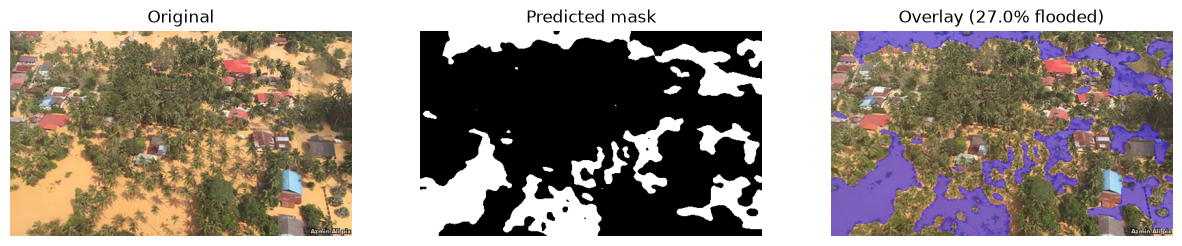

In [3]:
arr = np.array(img)
overlay = arr.copy()
overlay[mask == 1] = (0.5 * arr[mask == 1] + 0.5 * np.array([0, 0, 255])).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(arr);               ax[0].set_title("Original")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Predicted mask")
ax[2].imshow(overlay);           ax[2].set_title(f"Overlay ({mask.mean() * 100:.1f}% flooded)")
for a in ax: a.axis("off")
plt.show()

1013 IoU: 0.832


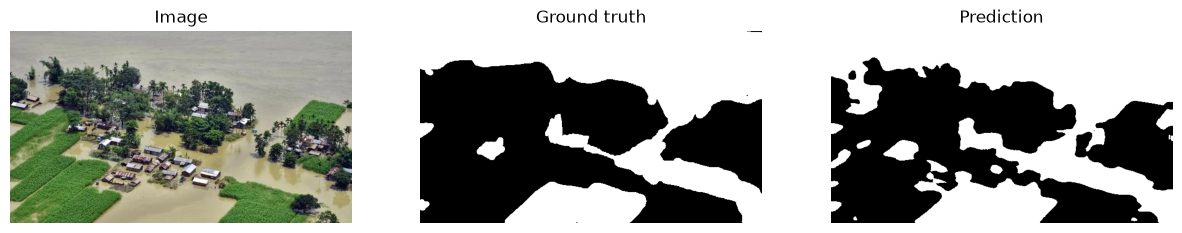

In [4]:
import pandas as pd
test_stems = pd.read_csv("data/split.csv").query("split == 'test'").stem.astype(str).tolist()
stem = test_stems[0]

img = Image.open(f"data/Image/{stem}.jpg").convert("RGB")
gt = np.array(Image.open(f"data/Mask/{stem}.png").convert("L")) > 127
pred = predict(model, img)

iou = (pred & gt).sum() / ((pred | gt).sum() + 1e-7)
print(stem, f"IoU: {iou:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img); ax[0].set_title("Image")
ax[1].imshow(gt, cmap="gray"); ax[1].set_title("Ground truth")
ax[2].imshow(pred, cmap="gray"); ax[2].set_title("Prediction")
for a in ax: a.axis("off")
plt.show()

In [ ]:
###ADD your image path to predict with your image

img = Image.open("path/to/your_image.jpg").convert("RGB") 
mask = predict(model, img)

FileNotFoundError: [Errno 2] No such file or directory: 'path/to/your_image.jpg'